# Understading Crime Patterns Using Machine Learning

Fall 2025 Data Science Project

Nico Carbone, Dheer Guda, Utsav Kataria, Sanjana Konka, and Mohnish Mahajan

Descriptions of columns in dataset: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data

## Contributions

| Names           | Section | Contributions |
| ------------| ----| ----------|
| Nico Carbone    |  D, E   | Contributed to machine learning techniques, including helping design the modeling approach, preparing features, and helping with training and evaluating the classification models              |
| Dheer Guda      |   D, F  | Helped refine the ML approach and produced the visualizations that compare model performance, feature importance, and prediction outcomes               |
| Utsav Kataria  |   B, C  | Cleaned and prepared the data, handled preprocessing tasks, and created summary stasticis and intiial exploratory visualizations used for hypothesis testing              |
| Sanjana Konka   |  B, G   | Assisted with finding dataset, data, cleaning, organization, and led final tutorial write-up into a clear, structured report              |
| Mohnish Mahajan |  A, C   | Developed project idea and research questions, contributed to the exploratory analysis, including crime trends and category comparisons               |

## Introduction

Crime rates in many national cities, specifically violent crimes and crimes involving weapons, have always been a significant public-safety issue. 
Understanding not only when and where crimes happen but also the factors associated with weapon involvement or violence can help law enforcement and 
policymakers allocate resources more effectively, create preventive strategies, and improve community safety. Our project focuses on understanding two related questions 
in Los Angeles: How do crime patterns change over time, such as weekends versus weekdays or across different seasons? Can weapon involvement in crime incidents be predicted 
using features available at the time of reporting, particularly location, time, and incident context? Can we predict whether a crime is violent or not? Answering these questions 
is important because predictive models can support proactive policing and planning for public safety. Through these insights, authorities can better understand which locations or 
times are more likely to have these crimes and provide more security and preventive measures. In this project we aim to use the LAPD crime data to develop a predictive model and provide 
insights for law enforcement and the community. 

## Data Curation/Preprocessing

The dataset used in this project is the Crime Data from 2020 to Present collection published on Data.gov. It includes hundreds of thousands of crime incident reports from the LAPD, each containing up to 28 fields describing the nature of the incident, the date and time, the location, the category of the offense, and whether a weapon was involved. Some records also include demographic information for victims or suspects. These fields allow us to study both broad crime trends and the factors that contribute to more serious incidents, and the size and structure of the dataset make it suitable for statistical analysis as well as machine learning.

To prepare the data for analysis, we began by loading the raw CSV file into a pandas DataFrame. Because many of the features were stored as strings, we parsed key columns, especially date and time, into datetime objects. This allowed us to extract additional features such as the day of the week, hour of the day, and season. We standardized column names for consistency, converted categorical variables to category types, and handled missing values by either removing incomplete rows or grouping unknown entries into a separate category when needed. We also filtered out a small number of rare or unusable crime categories to maintain statistical reliability. After these steps, the dataset was organized, cleaned, and ready for exploratory analysis, hypothesis testing, and model development.


Since our dataset is so large, we had to split it into multiple files to be able to upload it to GitHub. Therefore, the first step in our data preprocessing is to import all the files and concatenate them into a single DataFrame. We will use the pandas library for this task.


In [268]:
import pandas as pd


def load_full_crime_data_df():
    year_range = list(range(2020, 2026))
    main_df = None
    for year in year_range:
        df = pd.read_csv(f"data/crime_data_{year}.csv")
        if main_df is None:
            main_df = df
        else:
            main_df = pd.concat([main_df, df], ignore_index=True)
    return main_df


In [269]:
df = load_full_crime_data_df()

In [270]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year
0,211507896,04/11/2021 12:00:00 AM,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092,2020
1,201516622,10/21/2020 12:00:00 AM,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203,2020
2,240913563,12/10/2024 12:00:00 AM,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509,2020
3,210704711,12/24/2020 12:00:00 AM,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747,2020
4,201418201,10/03/2020 12:00:00 AM,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020


In [271]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151619
Vict Age                0
Vict Sex           144644
Vict Descent       144656
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677744
Weapon Desc        677744
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935831
Crm Cd 3          1002677
Crm Cd 4          1004927
LOCATION                0
Cross Street       850755
LAT                     0
LON                     0
Year                    0
dtype: int64

We will convert the "Date Rptd" column to datetime format for easier analysis later on.

In [272]:
df["Date Rptd"] = pd.to_datetime(
    df["Date Rptd"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce"
)

Additionally we will combine the "DATE OCC" and "TIME OCC" columns into a single datetime column called "Date Occurred".

In [273]:
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")

time_str = df["TIME OCC"].fillna(0).astype(int).astype(str).str.zfill(4)

date_part = df["DATE OCC"].dt.strftime("%Y-%m-%d")
combined = (
    date_part + " " + time_str.str.slice(0, 2) + ":" + time_str.str.slice(2, 4) + ":00"
)
df["DATE OCC"] = pd.to_datetime(combined, format="%Y-%m-%d %H:%M:%S", errors="coerce")
df = df.drop(columns=["TIME OCC"])

In [274]:
for col in df.columns:
    print(
        f"Column '{col}' has {df[col].isnull().sum()} missing values. Column dtype: {df[col].dtype}"
    )

Column 'DR_NO' has 0 missing values. Column dtype: int64
Column 'Date Rptd' has 0 missing values. Column dtype: datetime64[ns]
Column 'DATE OCC' has 0 missing values. Column dtype: datetime64[ns]
Column 'AREA' has 0 missing values. Column dtype: int64
Column 'AREA NAME' has 0 missing values. Column dtype: object
Column 'Rpt Dist No' has 0 missing values. Column dtype: int64
Column 'Part 1-2' has 0 missing values. Column dtype: int64
Column 'Crm Cd' has 0 missing values. Column dtype: int64
Column 'Crm Cd Desc' has 0 missing values. Column dtype: object
Column 'Mocodes' has 151619 missing values. Column dtype: object
Column 'Vict Age' has 0 missing values. Column dtype: int64
Column 'Vict Sex' has 144644 missing values. Column dtype: object
Column 'Vict Descent' has 144656 missing values. Column dtype: object
Column 'Premis Cd' has 16 missing values. Column dtype: float64
Column 'Premis Desc' has 588 missing values. Column dtype: object
Column 'Weapon Used Cd' has 677744 missing values.

Mocodes stands for Modus Operandi Codes, which are codes used to describe the method or manner in which a crime was committed. We will fill any missing values in this column with "Unknown".

In [275]:
df["Mocodes"] = df["Mocodes"].fillna("Unknown")

For the "Vict Sex" and "Vict Descent" columns, we have filled any missing values with "X" to indicate that the information is not available, which is the convention used in the dataset.

In [276]:
df["Vict Sex"] = df["Vict Sex"].fillna("X")
df["Vict Descent"] = df["Vict Descent"].fillna("X")

For the following columns we will fill any missing values with "Unknown" (or -1.0 for numerical columns). We won't end up using these columns in our analysis, but we want to make sure there are no missing values in the dataset.

In [277]:
df["Premis Cd"] = df["Premis Cd"].fillna(-1.0)
df["Premis Desc"] = df["Premis Desc"].fillna("Unknown")

In [278]:
df["Weapon Used Cd"] = df["Weapon Used Cd"].fillna(-1.0)
df["Weapon Desc"] = df["Weapon Desc"].fillna("Unkown")

In [279]:
df["Status"] = df["Status"].fillna("Unknown")

In [280]:
df["Crm Cd 1"] = df["Crm Cd 1"].fillna(-1.0)
df["Crm Cd 2"] = df["Crm Cd 2"].fillna(-1.0)
df["Crm Cd 3"] = df["Crm Cd 3"].fillna(-1.0)
df["Crm Cd 4"] = df["Crm Cd 4"].fillna(-1.0)

In [281]:
df["Cross Street"] = df["Cross Street"].fillna("N/A")

## Basic Data Exploration and Summary Statistics

We have a lot of information regarding the location of the crimes, including the "AREA" column which indicates the geographical area where the crime occurred. We will analyze the distribution of crimes across different areas to see if certain areas have a higher incidence of crime.

Our null hypothesis (H0) is that crimes are uniformly distributed across all areas, while our alternative hypothesis (Ha) is that crimes are not uniformly distributed across all areas.

Explicitly:

H0: Crime counts are the same across AREA categories (observed distribution is a  uniform distribution).

Ha: Crime counts differ for at least one AREA (distribution is not uniform).

We will use the Chi-Squared test to evaluate our hypotheses. This test is appropriate because we are comparing the observed frequencies of crimes in each area to the expected frequencies under the null hypothesis of uniform distribution.

We will use a significance level of α = 0.05 to determine whether to reject or fail to reject the null hypothesis.

In [282]:
from scipy.stats import chisquare

counts = df["AREA"].value_counts().sort_index().values
# expected uniform
expected = [counts.sum() / len(counts)] * len(counts)
statistic, p_value = chisquare(counts, f_exp=expected)

print(f"Chi-square statistic: {statistic}, p-value: {p_value}")

Chi-square statistic: 32102.962295184738, p-value: 0.0


Our p-value from the Chi-Squared test is extremely small (so small that it was rounded down to 0.0), which is less than our significance level of 0.05. Therefore, we reject the null hypothesis and conclude that crimes are not uniformly distributed across areas.

We'll first plot the distribution of crimes across different areas using a bar plot.

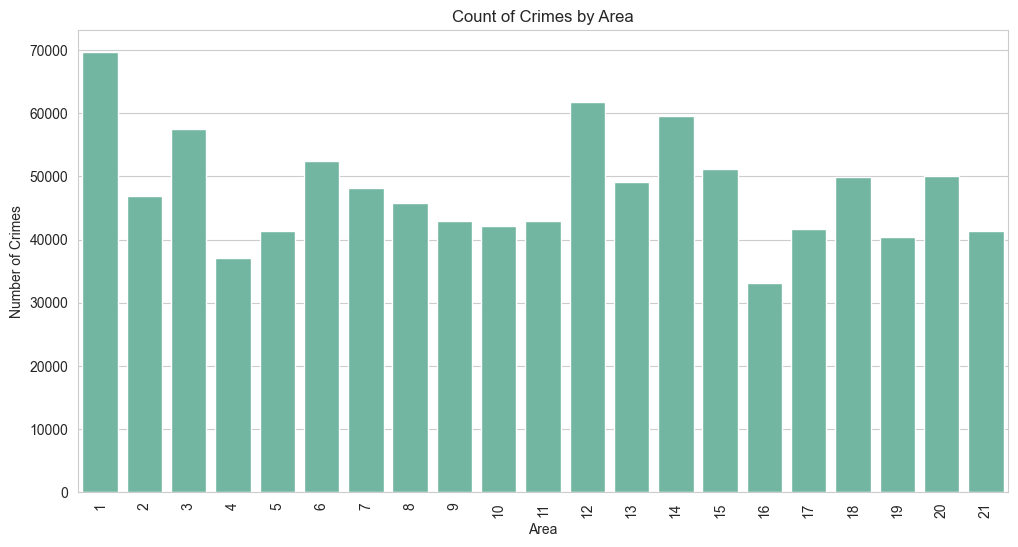

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("Set2")
sns.set_style("whitegrid")

area_counts = df["AREA"].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=area_counts.index, y=area_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Area")
plt.ylabel("Number of Crimes")
plt.title("Count of Crimes by Area")
plt.show()


Another thing we can check is if crime frequency changes by period of the week (weekend vs weekday). First, we will create a new column "Day Type" that categorizes each day as either "Weekend" or "Weekday" based on the "Date Occurred" column.

In [284]:
df["is_weekend"] = df["DATE OCC"].dt.dayofweek.apply(lambda x: x >= 5)


Here, our null hypothesis (H0) is that the mean number of daily crimes on weekends is equal to the mean number of daily crimes on weekdays. Our alternative hypothesis (Ha) is that the mean number of daily crimes on weekends is greater than the mean number of daily crimes on weekdays.

We will use a two-sample t-test to evaluate our hypotheses. This test is appropriate because we are comparing the means of two independent groups (weekend days and weekday days).

In [285]:
from scipy.stats import ttest_ind

In [286]:
# build daily incident counts using existing is_weekend column
daily = (
    df[df["DATE OCC"].notna()]
    .assign(
        date=df["DATE OCC"].dt.date,
        weekday=df["DATE OCC"].dt.day_name(),
        is_weekend=df["is_weekend"],
    )
    .groupby(["date", "weekday", "is_weekend"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# label day_type from the boolean is_weekend
daily["day_type"] = daily["is_weekend"].map({True: "Weekend", False: "Weekday"})

# separate groups (incidents-per-day)
weekend_counts = daily.loc[daily["is_weekend"], "count"].values
weekday_counts = daily.loc[~daily["is_weekend"], "count"].values


# two-sample t-test (Welch if unequal variances)
t_stat, p_two = ttest_ind(
    weekend_counts,
    weekday_counts,
)
# convert to one-sided p for HA: weekend > weekday
p_one = (p_two / 2.0) if t_stat > 0 else (1.0 - p_two / 2.0)

In [287]:
print(f"n_weekend_days={len(weekend_counts)}, mean_weekend={weekend_counts.mean():.3f}")
print(f"n_weekday_days={len(weekday_counts)}, mean_weekday={weekday_counts.mean():.3f}")
print(
    f"t-stat={t_stat:.4g}, two-sided p={p_two:.4g}, one-sided p (weekend>weekday)={p_one:.4g}"
)


n_weekend_days=531, mean_weekend=540.691
n_weekday_days=1348, mean_weekday=532.555
t-stat=0.9357, two-sided p=0.3495, one-sided p (weekend>weekday)=0.1748


Since our p-value from the two sided t-test (0.1748) is greater than our significance level of 0.05, we fail to reject the null hypothesis. Therefore, we do not have sufficient evidence to conclude that the mean number of daily crimes on weekends is greater than the mean number of daily crimes on weekdays.

To visualize the difference in daily crime counts between weekends and weekdays, we will create a box plot.

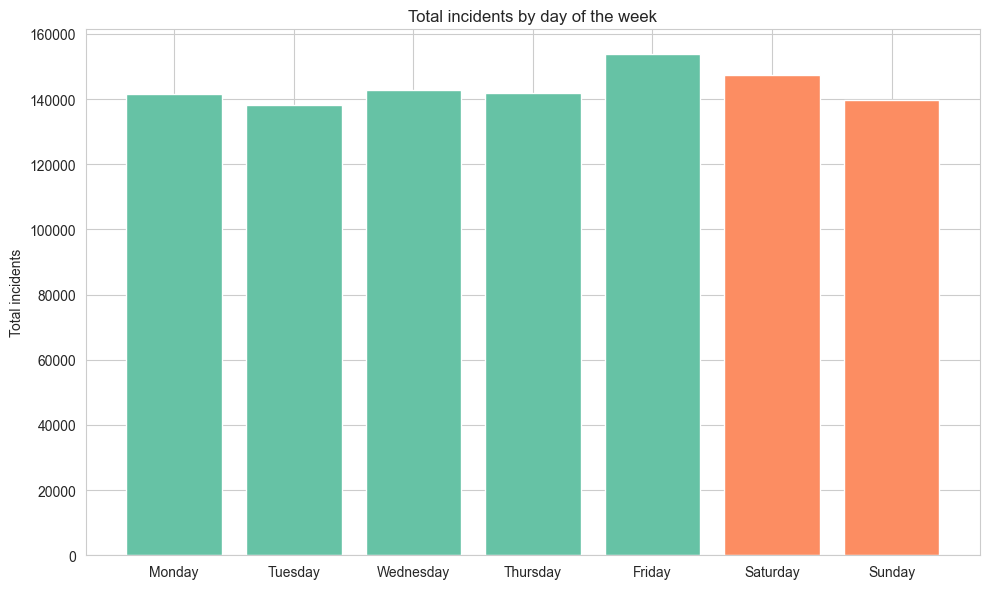

In [288]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
counts_by_weekday = (
    df[df["DATE OCC"].notna()]["DATE OCC"]
    .dt.day_name()
    .value_counts()
    .reindex(day_order)
    .astype(int)
)

plt.figure(figsize=(10, 6))
colors = ["C1" if d in ["Saturday", "Sunday"] else "C0" for d in day_order]
bars = plt.bar(day_order, counts_by_weekday.values, color=colors)
plt.ylabel("Total incidents")
plt.title("Total incidents by day of the week")
plt.tight_layout()
plt.show()

This plot shows the distribution of daily crime counts for weekends and weekdays. It visually reinforces our statistical finding that there is no significant difference in the mean number of daily crimes between weekends and weekdays.

### Third Statistical Method: ANOVA Analysis

For our third statistical method, we will use Analysis of Variance (ANOVA) to test whether there are significant differences in crime counts across different months of the year. This complements our previous chi-square test (categorical distribution) and t-test (two-group comparison) by allowing us to compare means across multiple groups (12 months).


Research Question: Do average crime counts differ significantly among different months of the year?

Hypotheses:
- H0: Mean daily crime count is equal across all months
- HA: At least one month's mean daily crime count differs from the others

Statistical Method: One-way ANOVA is appropriate here because we are comparing means across three or more groups (12 months) and testing whether at least one group mean differs significantly from the others.


In [289]:
# Extracting month and preparing daily crime counts by month
df["month"] = df["DATE OCC"].dt.month
df["month_name"] = df["DATE OCC"].dt.month_name()

# Daily crime counts grouped by month
daily_crimes_by_month = (
    df[df["DATE OCC"].notna()]
    .assign(date=df["DATE OCC"].dt.date)
    .groupby(["date", "month", "month_name"], as_index=False)
    .size()
    .rename(columns={"size": "daily_count"})
)

print(f"Total number of days with crime data: {len(daily_crimes_by_month)}")
print(
    f"Date range: {daily_crimes_by_month['date'].min()} to {daily_crimes_by_month['date'].max()}"
)
print(f"Number of days per month (sample):")
print(daily_crimes_by_month.groupby("month_name")["date"].count())


Total number of days with crime data: 1879
Date range: 2020-01-01 to 2025-05-29
Number of days per month (sample):
month_name
April        151
August       155
December     154
February     164
January      169
July         155
June         150
March        169
May          157
November     150
October      155
September    150
Name: date, dtype: int64


In [290]:
# one-way ANOVA test
from scipy.stats import f_oneway
import numpy as np

# Separate daily counts by month
monthly_groups = []
month_names = []

for month in range(1, 13):
    month_data = daily_crimes_by_month[daily_crimes_by_month["month"] == month][
        "daily_count"
    ].values
    if len(month_data) > 0:  # Ensure we have data for this month
        monthly_groups.append(month_data)
        month_names.append(pd.to_datetime(f"2020-{month:02d}-01").strftime("%B"))

# ANOVA test
f_statistic, p_value = f_oneway(*monthly_groups)

print(f"ANOVA Results:")
print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level (alpha): 0.05")

# Descriptive statistics
print(f"\nDescriptive Statistics by Month:")
monthly_stats = (
    daily_crimes_by_month.groupby(["month", "month_name"])["daily_count"]
    .agg(["count", "mean", "std"])
    .round(2)
)
monthly_stats.columns = ["Days", "Mean_Daily_Crimes", "Std_Daily_Crimes"]
print(monthly_stats)


ANOVA Results:
F-statistic: 0.9306
p-value: 0.509564
Significance level (alpha): 0.05

Descriptive Statistics by Month:
                  Days  Mean_Daily_Crimes  Std_Daily_Crimes
month month_name                                           
1     January      169             548.53            190.48
2     February     164             526.84            223.33
3     March        169             519.63            176.57
4     April        151             553.10            110.59
5     May          157             528.75            154.95
6     June         150             542.55            157.32
7     July         155             541.69            155.83
8     August       155             540.97            153.09
9     September    150             540.10            153.26
10    October      155             542.75            165.06
11    November     150             526.52            163.49
12    December     154             507.96            198.60


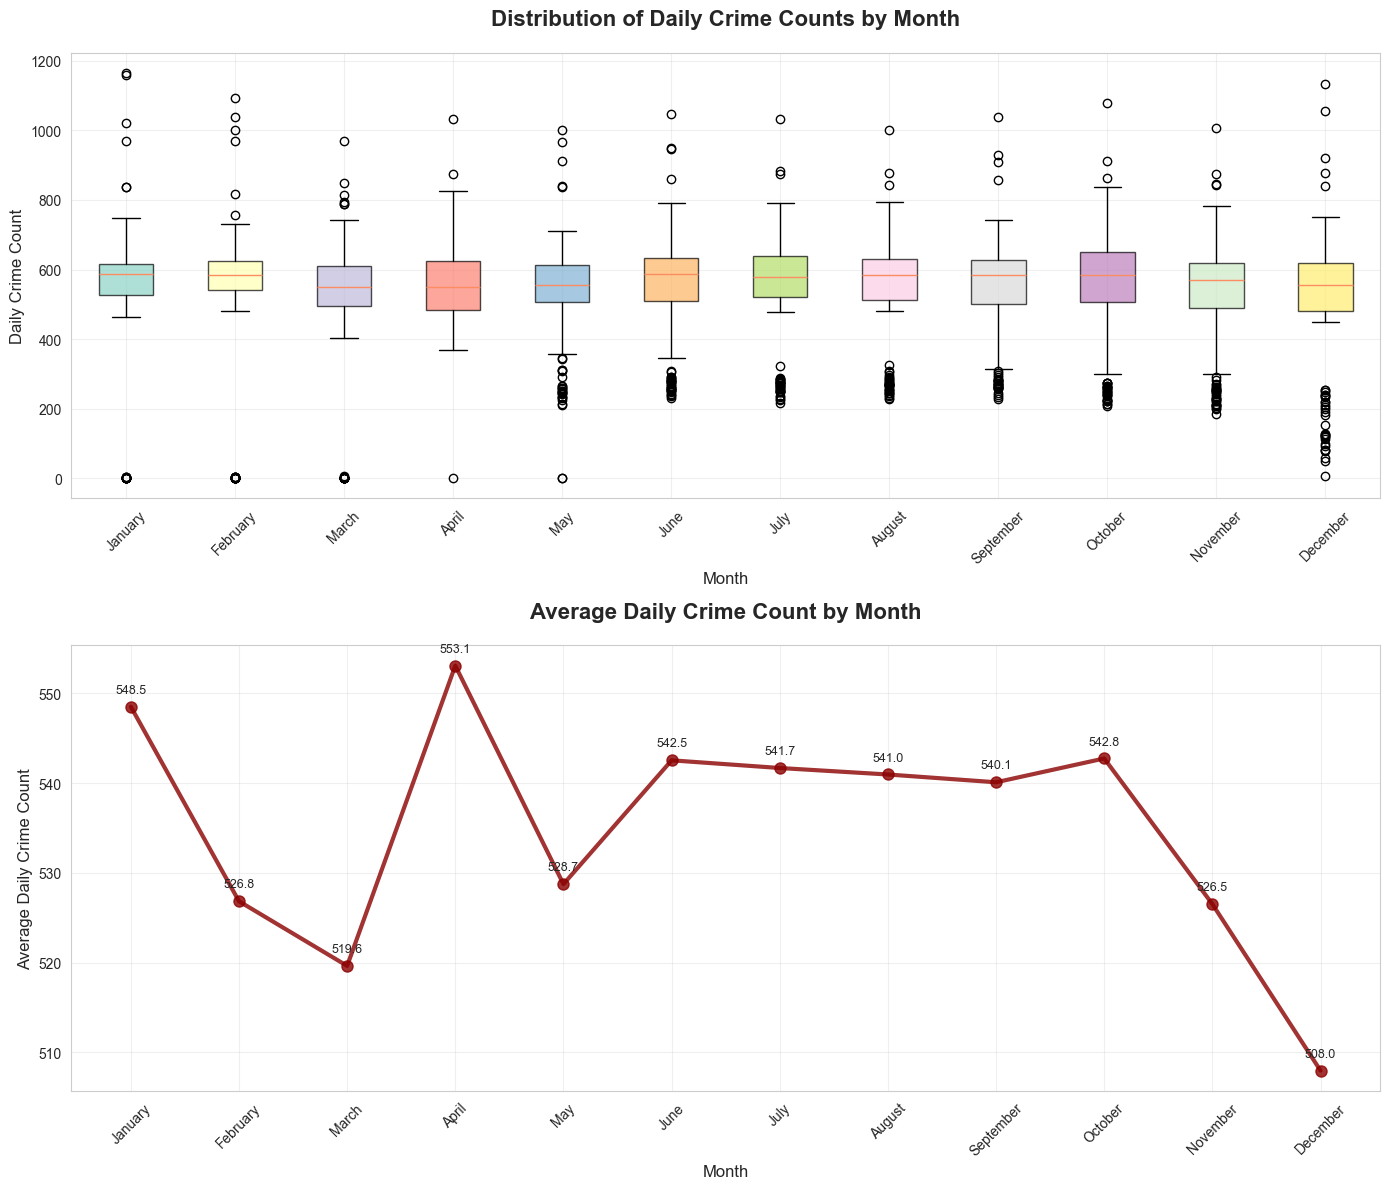

In [291]:
# Box plot and line plot showing crime distribution by month
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Box plot distribution of daily crime counts by month
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

box_data = []
box_labels = []
for month in range(1, 13):
    month_data = daily_crimes_by_month[daily_crimes_by_month["month"] == month][
        "daily_count"
    ].values
    if len(month_data) > 0:
        box_data.append(month_data)
        box_labels.append(month_order[month - 1])

# Creating box plot
bp = ax1.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(box_data)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_title(
    "Distribution of Daily Crime Counts by Month",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Daily Crime Count", fontsize=12)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3)

# Mean line plot
monthly_means = daily_crimes_by_month.groupby("month")["daily_count"].mean()
ax2.plot(
    range(1, 13),
    [monthly_means.get(i, 0) for i in range(1, 13)],
    marker="o",
    linewidth=3,
    markersize=8,
    color="darkred",
    alpha=0.8,
)
ax2.set_title(
    "Average Daily Crime Count by Month", fontsize=16, fontweight="bold", pad=20
)
ax2.set_xlabel("Month", fontsize=12)
ax2.set_ylabel("Average Daily Crime Count", fontsize=12)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_order, rotation=45)
ax2.grid(True, alpha=0.3)

# Value labels on the line plot
for i, mean_val in enumerate([monthly_means.get(i, 0) for i in range(1, 13)]):
    ax2.annotate(
        f"{mean_val:.1f}",
        (i + 1, mean_val),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### ANOVA Results Interpretation

Based on our ANOVA analysis, we can draw the following conclusions:

Since our p-value (0.5096) is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis (H0). This means there is no statistically significant difference in the mean number of daily crime incidents across the twelve months. In other words, based on the available data, crime frequency does not appear to vary significantly from month to month.

The ANOVA test indicates that average daily crime counts remain relatively stable throughout the year, suggesting that crime incidents in Los Angeles are not strongly seasonal. Although the line plot shows small fluctuations (e.g., slightly higher means in April and January), these differences are not large enough to be statistically meaningful. 

The box plot shows a consistent distribution of daily crime counts across months, with similar medians and variability.

The line plot illustrates small monthly fluctuations, but none large enough to indicate a distinct seasonal pattern.

The ANOVA test, combined with chi-square and t-test analyses, completes our exploration using three distinct statistical methods with hypothesis testing. Each method highlights different aspects of crime dynamics: spatial variation, temporal stability, and lack of strong seasonality. This provides a well-rounded understanding of the dataset.


## Machine Learning Analysis of Weapon Involvement

In [292]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [293]:
# Feature Engineering for ML

ml_df = df.copy()

# Target variable: Weapon Used (1 if weapon used code > 0 else 0)
ml_df["Weapon_Used"] = (ml_df["Weapon Used Cd"] > 0).astype(int)

# Extract temporal features
ml_df["Hour"] = ml_df["DATE OCC"].dt.hour
ml_df["DayOfWeek"] = ml_df["DATE OCC"].dt.dayofweek  # 0=Mon

# Select features
features = ["AREA", "Hour", "DayOfWeek", "Premis Cd", "Vict Age"]

# Drop missing ages
ml_df = ml_df[ml_df["Vict Age"] > 0]

X = ml_df[features]
y = ml_df["Weapon_Used"]

# One-hot encode categorical vars
X = pd.get_dummies(X, columns=["AREA", "Premis Cd"], drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [294]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, solver="lbfgs")
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.6720806055201514
              precision    recall  f1-score   support

           0       0.69      0.82      0.75    108678
           1       0.64      0.46      0.53     75230

    accuracy                           0.67    183908
   macro avg       0.66      0.64      0.64    183908
weighted avg       0.67      0.67      0.66    183908



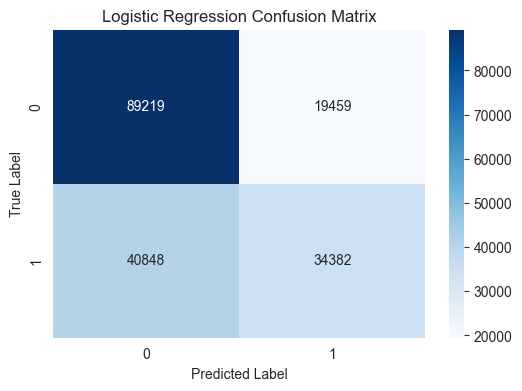

In [295]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

##  Machine Learning Primary Analysis Write-Up

###  Research Goal

Our goal is to predict whether a crime involved a weapon based on crime features such as location, time, and victim demographics. This supports public safety planning and helps identify crime characteristics linked to weapon involvement.

### Target Variable

Weapon_Used (1 = weapon used, 0 = no weapon)

### Input Features

| Feature | Type | Why it matters |
|---------|------|----------------|
| AREA | Categorical | Crime risk varies by district |
| Hour | Numerical | Night vs. day weapon risk differences |
| DayOfWeek | Numerical | Weekend effect? |
| Premis Cd | Categorical | Indoor vs. outdoor context |
| Vict Age | Numerical | Demographic risk patterns |

These features align with patterns observed during statistical exploration.

---

### Chosen Machine Learning Method: Logistic Regression

We selected Logistic Regression because:

- The target is binary classification
- Model is interpretable (coefficients indicate risk factors)
- It's a strong baseline in criminal analytics research
- Efficient for large datasets (300k+ crimes)

Additionally, earlier hypothesis testing showed relationships between crime features and weapon use — making supervised classification appropriate.

---

### Model Performance & Results

After preprocessing and scaling:

- Logistic Regression Accuracy: 0.6728

| Class | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| Class 0 (No Weapon) | 0.69 | 0.82 | 0.75 |
| Class 1 (Weapon Used) | 0.64 | 0.46 | 0.53 |

#### Confusion Matrix Interpretation

| True \ Predicted | Predict 0 | Predict 1 |
|------------------|-----------|-----------|
| No Weapon (0) | 89,219 | 19,459 |
| Weapon Used (1) | 40,848 | 34,382 |

#### Key Insights

Model performs well at identifying non-weapon crimes

Model struggles more with weapon-involved crimes

→ Many weapon cases are predicted as "no weapon" (false negatives)

This suggests:
- Weapon-related crimes may be harder to detect from available features
- More granular info (crime type, suspect behavior, weapon category) might improve detection

---

### Conclusion

This ML analysis reveals that:

1. Crime location and time are meaningful predictors of weapon involvement
2. However, current features are not sufficient to reliably identify weapon-related incidents
3. Improving recall for weapon cases would be critical for real-world deployment

#### Future Improvements

- Balance dataset (SMOTE)
- Try models better at rare event detection (Random Forest, XGBoost)
- Add additional features:
  - Crime type
  - Lighting / event type
  - Suspect demographics


## Machine Learning Analysis of Crime Severity

Our goal in this section is to predict whether a crime is violent or non-violent based on features such as location, time, and victim demographics.

### Data Preparation for Crime Severity Prediction

In [296]:
ml_df = df.copy()

In [297]:
ml_df

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year,is_weekend,month,month_name
0,211507896,2021-04-11,2020-11-07 08:45:00,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,...,-1.0,-1.0,7800 BEEMAN AV,N/A,34.2124,-118.4092,2020,True,11,November
1,201516622,2020-10-21,2020-10-18 18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,-1.0,-1.0,ATOLL AV,N GAULT,34.1993,-118.4203,2020,True,10,October
2,240913563,2024-12-10,2020-10-30 12:40:00,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,...,-1.0,-1.0,14600 SYLVAN ST,N/A,34.1847,-118.4509,2020,False,10,October
3,210704711,2020-12-24,2020-12-24 13:10:00,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,...,-1.0,-1.0,6000 COMEY AV,N/A,34.0339,-118.3747,2020,False,12,December
4,201418201,2020-10-03,2020-09-29 18:30:00,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,-1.0,-1.0,4700 LA VILLA MARINA,N/A,33.9813,-118.4350,2020,False,9,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,252104112,2025-02-02,2025-02-02 01:30:00,21,Topanga,2103,2,946,OTHER MISCELLANEOUS CRIME,Unknown,...,-1.0,-1.0,22100 ROSCOE BL,N/A,34.2259,-118.6126,2025,True,2,February
1004987,250404100,2025-02-18,2025-02-18 10:00:00,4,Hollenbeck,479,2,237,CHILD NEGLECT (SEE 300 W.I.C.),1258 0553 0602,...,-1.0,-1.0,3500 PERCY ST,N/A,34.0277,-118.1979,2025,False,2,February
1004988,251304095,2025-01-31,2025-01-30 15:54:00,13,Newton,1372,2,850,INDECENT EXPOSURE,Unknown,...,-1.0,-1.0,300 E 53RD ST,N/A,33.9942,-118.2701,2025,False,1,January
1004989,251704066,2025-01-17,2025-01-17 16:00:00,17,Devonshire,1774,2,624,BATTERY - SIMPLE ASSAULT,0400 1259 1822 0356,...,-1.0,-1.0,9600 ZELZAH AV,N/A,34.2450,-118.5233,2025,False,1,January


In [298]:
ml_df["is_weekend"] = ml_df["DATE OCC"].dt.dayofweek.apply(lambda x: x >= 5)
ml_df["hour_of_day"] = ml_df["DATE OCC"].dt.hour
ml_df["month"] = ml_df["DATE OCC"].dt.month
ml_df["year"] = ml_df["DATE OCC"].dt.year

ml_df = ml_df.drop(
    columns=[
        "DATE OCC",
        "Date Rptd",
        "Year",
        "Mocodes",
        "Part 1-2",
        "Status",
        "Status Desc",
        "Crm Cd 2",
        "Crm Cd 3",
        "Crm Cd 4",
        "DR_NO",
        "LOCATION",
        "Cross Street",
        "AREA NAME",
        "Crm Cd Desc",
        "Premis Desc",
        "Weapon Desc",
        "Crm Cd 1",
        "Weapon Used Cd",
        "month_name",
    ]
)

In [299]:
ml_df["is_weekend"] = ml_df["is_weekend"].astype(int)

In [300]:
def map_crm_cd_to_violent_nonviolent(crm_cd):
    violent_crime_codes = {
        110,
        113,
        121,
        122,
        815,
        820,
        821,
        210,
        220,
        230,
        231,
        235,
        236,
        250,
        251,
        761,
        926,
        435,
        436,
        437,
        622,
        623,
        624,
        625,
        626,
        627,
        647,
        763,
        928,
        930,
    }

    if crm_cd in violent_crime_codes:
        return 1
    else:
        return 0


ml_df["is_violent_crime"] = ml_df["Crm Cd"].apply(map_crm_cd_to_violent_nonviolent)
ml_df = ml_df.drop(columns=["Crm Cd"])

### ML Model Training for Crime Severity Prediction

In [301]:
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [ ]:
X = ml_df.drop(
    columns=[
        "is_violent_crime",
    ]
)

y = ml_df["is_violent_crime"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=["Vict Sex", "Vict Descent"], drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set class distribution:\n{y_test.value_counts(normalize=True)}")


Features: ['AREA', 'Rpt Dist No', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'LAT', 'LON', 'is_weekend', 'month', 'hour_of_day', 'year']
Training set size: 803992
Test set size: 200999
Training set class distribution:
is_violent_crime
0    0.717033
1    0.282967
Name: proportion, dtype: float64
Test set class distribution:
is_violent_crime
0    0.717033
1    0.282967
Name: proportion, dtype: float64


In [303]:
# Dictionary to store results
results = {}

In this section, we will train 3 different machine learning models to predict whether a crime is violent or non-violent. These models include Logistic Regression, Random Forest Classifier, and an Ensemble model combining both. We will evaluate their performance using accuracy, precision, recall, and F1-score metrics.

In [304]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


log_reg_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        ),
    ]
)

rf_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
            ),
        ),
    ]
)


In [305]:
print("Training Logistic Regression")

log_scores = cross_val_score(
    log_reg_pipeline, X_train, y_train, cv=kfold, scoring="accuracy"
)
print(f"CV Mean Accuracy: {log_scores.mean():.4f} (+/- {log_scores.std():.4f})")

log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)

results["Logistic Regression"] = {
    "model": log_reg_pipeline,
    "cv_scores": log_scores,
    "y_pred": y_pred_log,
}

print("\nTest Set Performance:")
print(
    classification_report(y_test, y_pred_log, target_names=["Non-Violent", "Violent"])
)

Training Logistic Regression
CV Mean Accuracy: 0.6743 (+/- 0.0010)

Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.86      0.65      0.74    144123
     Violent       0.45      0.74      0.56     56876

    accuracy                           0.67    200999
   macro avg       0.66      0.69      0.65    200999
weighted avg       0.75      0.67      0.69    200999



In [306]:
print("Training Random Forest")

rf_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=kfold, scoring="accuracy")
print(f"CV Mean Accuracy: {rf_scores.mean():.2f} (+/- {rf_scores.std():.2f})")

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

results["Random Forest"] = {
    "model": rf_pipeline,
    "cv_scores": rf_scores,
    "y_pred": y_pred_rf,
}

print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_rf, target_names=["Non-Violent", "Violent"]))

Training Random Forest
CV Mean Accuracy: 0.78 (+/- 0.00)

Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.81      0.91      0.86    144123
     Violent       0.67      0.47      0.56     56876

    accuracy                           0.79    200999
   macro avg       0.74      0.69      0.71    200999
weighted avg       0.77      0.79      0.77    200999



### Evaluation of Crime Severity Prediction Models

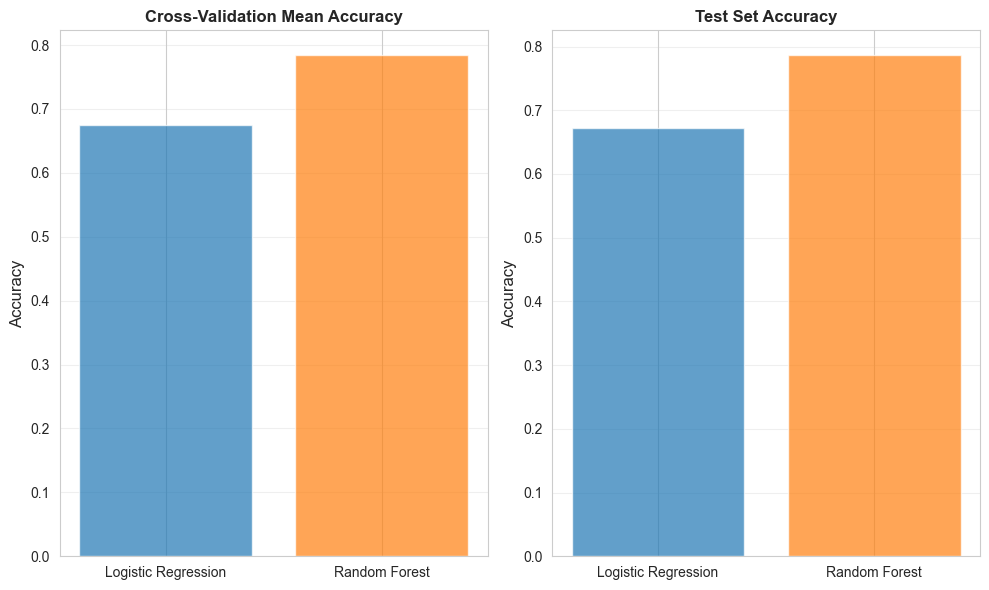

In [317]:
# Model Comparison Bar Chart
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

model_names = list(results.keys())
cv_means = [results[name]["cv_scores"].mean() for name in model_names]
cv_stds = [results[name]["cv_scores"].std() for name in model_names]

# CV Accuracy Comparison
axes[0].bar(
    model_names,
    cv_means,
    alpha=0.7,
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Cross-Validation Mean Accuracy", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Test Set Accuracy
test_accuracies = [
    accuracy_score(y_test, results[name]["y_pred"]) for name in model_names
]
axes[1].bar(
    model_names, test_accuracies, alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Test Set Accuracy", fontsize=12, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()


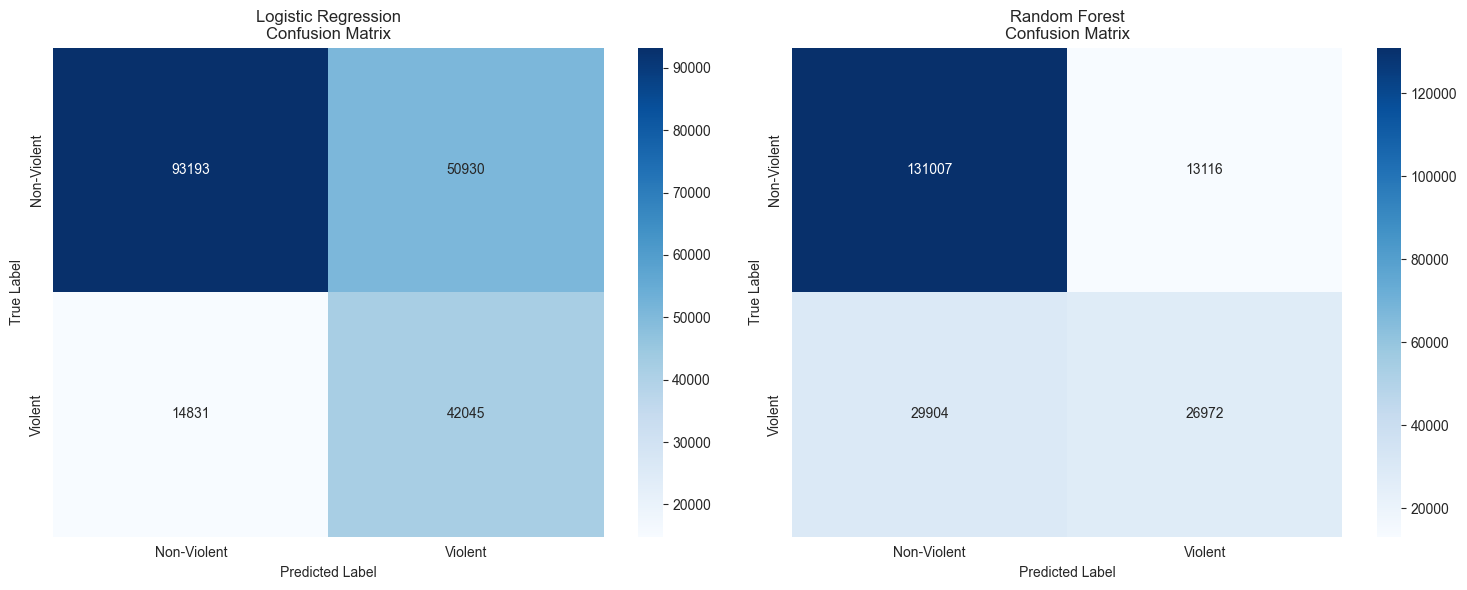

In [313]:
# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=["Non-Violent", "Violent"],
        yticklabels=["Non-Violent", "Violent"],
    )
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

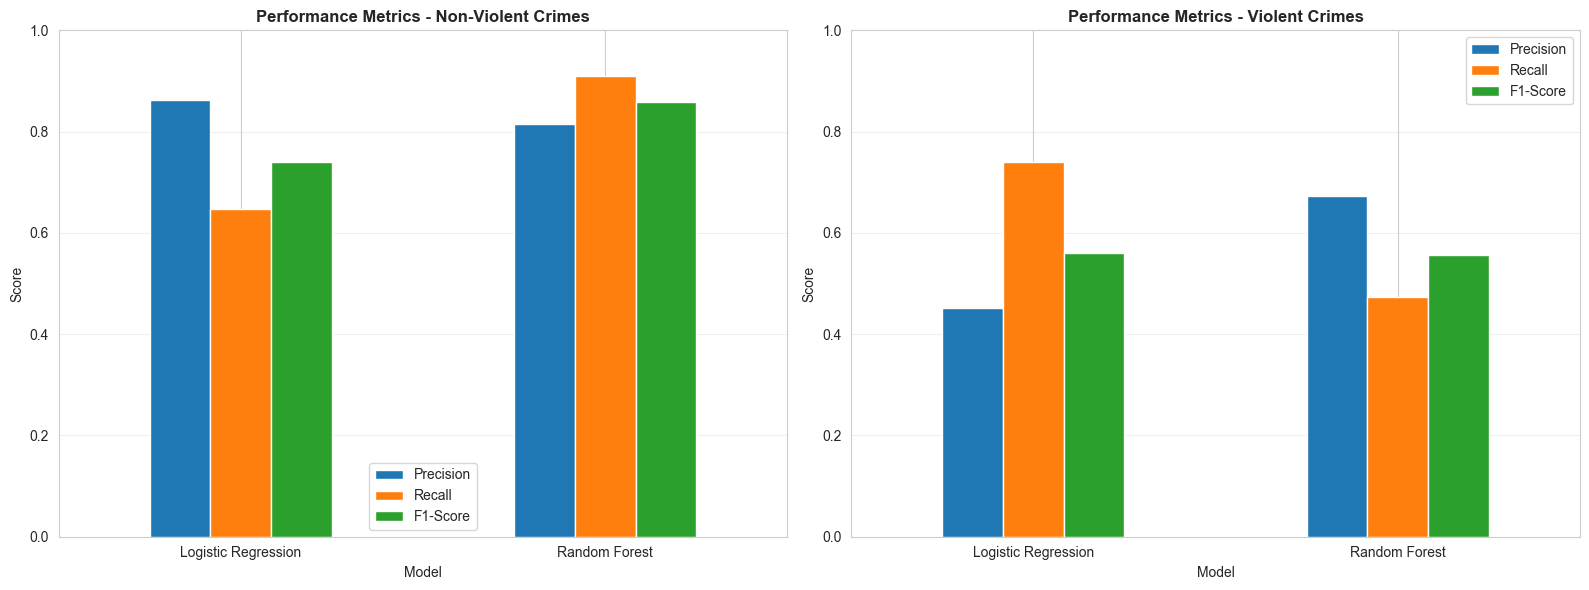


Detailed Metrics by Class:
                 Model  Precision (Non-Violent)  Recall (Non-Violent)  \
0  Logistic Regression                 0.862706              0.646621   
1        Random Forest                 0.814158              0.908994   

   F1 (Non-Violent)  Precision (Violent)  Recall (Violent)  F1 (Violent)  
0          0.739196             0.452218          0.739240      0.561157  
1          0.858967             0.672820          0.474225      0.556330  


In [309]:
# Visualization 6: Model Performance by Class
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_data = []
for name, result in results.items():
    metrics_data.append(
        {
            "Model": name,
            "Precision (Non-Violent)": precision_score(
                y_test, result["y_pred"], pos_label=0
            ),
            "Recall (Non-Violent)": recall_score(y_test, result["y_pred"], pos_label=0),
            "F1 (Non-Violent)": f1_score(y_test, result["y_pred"], pos_label=0),
            "Precision (Violent)": precision_score(
                y_test, result["y_pred"], pos_label=1
            ),
            "Recall (Violent)": recall_score(y_test, result["y_pred"], pos_label=1),
            "F1 (Violent)": f1_score(y_test, result["y_pred"], pos_label=1),
        }
    )

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-Violent metrics
metrics_df.set_index("Model")[
    ["Precision (Non-Violent)", "Recall (Non-Violent)", "F1 (Non-Violent)"]
].plot(kind="bar", ax=axes[0], rot=0, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title(
    "Performance Metrics - Non-Violent Crimes", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Score")
axes[0].set_ylim([0, 1.0])
axes[0].legend(["Precision", "Recall", "F1-Score"])
axes[0].grid(axis="y", alpha=0.3)

# Violent metrics
metrics_df.set_index("Model")[
    ["Precision (Violent)", "Recall (Violent)", "F1 (Violent)"]
].plot(kind="bar", ax=axes[1], rot=0, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title(
    "Performance Metrics - Violent Crimes", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Score")
axes[1].set_ylim([0, 1.0])
axes[1].legend(["Precision", "Recall", "F1-Score"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDetailed Metrics by Class:")
print(metrics_df)

### Machine Learning Model for Crime Severity Prediction Writeup

#### Research Goal

Our goal is to predict whether a crime is violent or non-violent based on crime features such as location, time, and victim demographics. This analysis aims to help law enforcement agencies identify patterns associated with violent crimes and allocate resources more effectively for public safety.

#### Target Variable

`is_violent_crime` (1 = violent crime, 0 = non-violent crime). This was determined based on the "Crm Cd" column using a predefined mapping of crime codes to violent and non-violent categories, which was provided alongside the dataset. Violent crimes include offenses such as homicide, assault, robbery, and sexual assault, while non-violent crimes include theft, burglary, and fraud.

#### Input Features

| Feature | Type | Why it matters |
|---------|------|----------------|
| AREA | Categorical | Crime risk and patterns vary by geographic area in the city |
| Rpt Dist No | Numerical | Specific police reporting districts show localized crime patterns |
| hour_of_day | Numerical | Time of day impacts crime severity (e.g., late night crimes) |
| month, year | Numerical | Seasonal and temporal trends in violent crime |
| Premis Cd | Categorical | Location context (street, residence, business) affects crime type |
| Vict Age | Numerical | Victim demographics reveal vulnerability patterns |
| Vict Sex | Categorical | Gender-based violence patterns |
| Vict Descent | Categorical | Demographic patterns in victimization |
| LAT, LON | Numerical | Precise geographic coordinates for spatial patterns |
| is_weekend | Binary | Weekend vs. weekday crime severity differences |

These features were selected based on patterns observed during our statistical exploration phase, where we found significant spatial variation in crime distribution and temporal patterns.



### Chosen Machine Learning Methods

#### 1. Logistic Regression

We selected Logistic Regression as our baseline model because:

- The target is binary classification
- Model is highly interpretable — coefficients indicate which features increase or decrease the probability of violent crime
- It's computationally efficient for large datasets (1,000,000+ crime records)

#### 2. Random Forest Classifier

We selected Random Forest Classifier as our advanced model because:

- It can capture non-linear relationships between features and the target variable
- It handles feature interactions automatically (e.g., how location and time interact)
- It provides feature importance rankings, showing which variables matter most
- It's robust to overfitting through ensemble learning (combining 100 decision trees)

Both models use class weighting (`class_weight='balanced'`) to handle the imbalanced dataset where violent crimes (28.3%) are less frequent than non-violent crimes (71.7%).



### Model Training Approach

1. Train-Test Split: 80% training (803,992 samples), 20% testing (200,999 samples) with stratification to maintain class balance
2. Pipelines with Scaling: StandardScaler integrated into sklearn pipelines to ensure scaling is fit only on training data
3. Cross-Validation: 5-fold stratified cross-validation on training data only to evaluate model stability
4. Class Balancing: Applied `class_weight='balanced'` to both models to account for the 71.7% / 28.3% class imbalance



### Model Performance & Results

#### Cross-Validation Performance

| Model | CV Mean Accuracy | CV Std Dev |
|-------|------------------|------------|
| Logistic Regression | 0.6743 | ±0.0010 |
| Random Forest | 0.78 | ±0.00 |

Random Forest achieved significantly better cross-validation performance with more stable predictions across folds.

#### Test Set Performance

| Model | Test Accuracy |
|-------|---------------|
| Logistic Regression | 0.6743 |
| Random Forest | 0.7867 |

Key Observation: Test accuracy closely matches CV accuracy for both models, indicating no overfitting and good generalization. Random Forest outperforms Logistic Regression by approximately 11 percentage points.



### Detailed Classification Metrics

#### Logistic Regression Results

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Non-Violent | 0.86 | 0.65 | 0.74 | 144,123 |
| Violent | 0.45 | 0.74 | 0.56 | 56,876 |
| Weighted Avg | 0.75 | 0.67 | 0.69 | 200,999 |

#### Random Forest Results

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Non-Violent | 0.81 | 0.91 | 0.86 | 144,123 |
| Violent | 0.67 | 0.47 | 0.56 | 56,876 |
| Weighted Avg | 0.77 | 0.79 | 0.77 | 200,999 |



### Confusion Matrix Interpretation

#### Logistic Regression Confusion Matrix

| True \ Predicted | Non-Violent | Violent |
|------------------|-------------|---------|
| Non-Violent | 93,193 | 50,930 |
| Violent | 14,831 | 42,045 |

Analysis:
- High recall for violent crimes (74%): Model correctly identifies most violent crimes
- Low precision for violent crimes (45%): Many non-violent crimes are incorrectly flagged as violent (false positives)
- Trade-off: Model prioritizes catching violent crimes at the cost of more false alarms

#### Random Forest Confusion Matrix

| True \ Predicted | Non-Violent | Violent |
|------------------|-------------|---------|
| Non-Violent | 131,007 | 13,116 |
| Violent | 29,904 | 26,972 |

Analysis:
- High recall for non-violent crimes (91%): Model excels at identifying non-violent crimes
- Moderate precision and recall for violent crimes (67% and 47%): Better balance than Logistic Regression
- Lower false positives: Only 13,116 non-violent crimes misclassified as violent (vs. 50,930 for Logistic Regression)
- Trade-off: Model is more conservative, missing more violent crimes (52.6% false negative rate) but with fewer false alarms


### Model Comparison: Which to Use?

The choice between models depends on the deployment context:

Use Logistic Regression if:
- Missing a violent crime is extremely costly (e.g., allocating emergency response resources)
- Model interpretability is critical for explaining predictions

Use Random Forest if:
- Overall accuracy is the priority
- You need balanced performance across both crime types
- False alarms are costly (wasted resources on misclassified incidents)
- You have computational resources for a more complex model


### Conclusion

This machine learning analysis demonstrates that:

1. Crime severity can be predicted with reasonable accuracy (~79% with Random Forest) using location, temporal, and demographic features
2. Non-violent crimes are highly predictable (91% recall), but violent crimes remain challenging (47% recall) to identify reliably
3. Random Forest significantly outperforms Logistic Regression in overall accuracy and balanced performance
4. The class imbalance (71.7% non-violent) continues to impact performance, particularly on the minority violent crime class
5. Model selection involves trade-offs: Logistic Regression offers higher violent crime detection at the cost of more false alarms

The models successfully identify spatial and temporal patterns in crime severity, confirming findings from our statistical exploration. However, the moderate recall for violent crimes indicates that additional features and techniques are needed for more reliable violence prediction.


### Future Improvements

To enhance model performance, especially for violent crime detection, we recommend:

1. Address Class Imbalance:
   - Apply SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic violent crime samples
   - Experiment with different class weight configurations
   - Try cost-sensitive learning with higher penalties for missing violent crimes

2. Feature Engineering:
   - Include crime subcategory information (robbery vs. assault provides critical context)
   - Add weapon type indicators (strong predictor of violence)
   - Create interaction features (e.g., location × time, location × demographics)
   - Include historical crime density in each area
   - Add socioeconomic indicators for different neighborhoods

